# 4. Method anchor

Part of the **[Fig. 1 chapter](fig1.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'{indir}clustering/tissue/L1/{g}/mCG_5kb_lsi.h5ad'`  ·  _raw embedding_
- `f'{indir}mCG_5kb_lsi.h5ad'`  ·  _raw embedding_
- `f'{indir}HiC_100kb_pca.h5ad'`  ·  _raw embedding_
- `f'{indir}5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.integration.seurat_class import SeuratIntegration

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/'


In [8]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [5]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
meta
# mcad = anndata.AnnData(obs=mcad.obs, obsm=mcad.obsm)
# mcad.write_h5ad('cell_86689_16tissue_100k3C_autosomal.h5ad')

,cluster,subtype,majortype,FinalmCReads,mCHFrac,mCGFrac,CisLongContact,Cis/Trans,Short/Long,Donor,...,L2_5kCG_tsne_0,L2_5kCG_tsne_1,L2_100k3C_tsne_0,L2_100k3C_tsne_1,Tissue_joint_tsne_0,Tissue_joint_tsne_1,Tissue_5kCG_tsne_0,Tissue_5kCG_tsne_1,Tissue_100k3C_tsne_0,Tissue_100k3C_tsne_1
cell,,,,,,,,,,,,,,,,,,,,,
B_IOBHL_Plate10-1-A17-B13,c17-c0,c17-b0,c17,1376030,0.011876,0.727399,186626,1.318921,0.446979,PT-1LGRB,...,-17.971627,4.153434,-22.665981,9.060770,-6.288688,-26.334854,-6.609710,29.406128,40.952520,-7.697411
B_IOBHL_Plate10-1-A17-B14,c17-c6,c17-b1,c17,2734154,0.009636,0.706403,359403,1.171003,-0.255793,PT-1LGRB,...,-5.820349,22.824702,-12.735919,7.324342,-25.717593,-24.931657,-19.312954,30.621607,41.040478,-9.829805
B_IOBHL_Plate10-1-A17-C2,c17-c1,c17-b1,c17,1634700,0.012266,0.702188,206047,1.302957,-0.584638,PT-1LGRB,...,6.485018,-3.822646,24.942036,11.727231,-34.630305,-5.052561,-23.342808,17.030080,17.876634,-26.870964
B_IOBHL_Plate10-1-A17-D13,c17-c0,c17-b0,c17,2407431,0.010201,0.698709,299610,1.023206,-0.656128,PT-1LGRB,...,-29.079593,-4.333497,-17.356194,3.569278,-6.711752,-23.788432,-11.666168,5.738039,42.743518,3.232084
B_IOBHL_Plate10-1-A17-D14,c17-c3,c17-b0,c17,2644447,0.008917,0.699867,301042,0.955355,-0.216212,PT-1LGRB,...,15.422152,-18.816535,12.912868,-22.098690,-16.407984,-6.717667,-22.993453,4.648533,21.032718,-3.972677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SkGcn_C1PWV_Plate8-6-O14-O12,c5-c0,c5-b1,c5,2156069,0.010095,0.711533,217305,1.398971,-0.664927,PT-1LVAN,...,3.892447,19.118928,26.810694,-22.743058,-24.343529,14.358791,0.177157,0.129099,-5.153260,24.715943
SkGcn_C1PWV_Plate8-6-O14-O24,c5-c7,c5-b0,c5,2452723,0.010655,0.712112,139778,1.005821,-0.570078,PT-1LVAN,...,-10.572230,-32.173632,2.237704,16.405757,-8.448709,-2.571831,18.061276,-23.459086,-24.406624,-7.877275
SkGcn_C1PWV_Plate8-6-O14-P12,c5-c4,c5-b1,c5,3255254,0.009585,0.701310,247522,1.286691,-0.869752,PT-1LVAN,...,30.272144,-19.227104,39.613908,-12.273716,0.570947,19.386031,-14.365126,-27.575202,-16.078713,28.340502


EG
27 components passed P cutoff of 0.05.
TrCo
21 components passed P cutoff of 0.05.


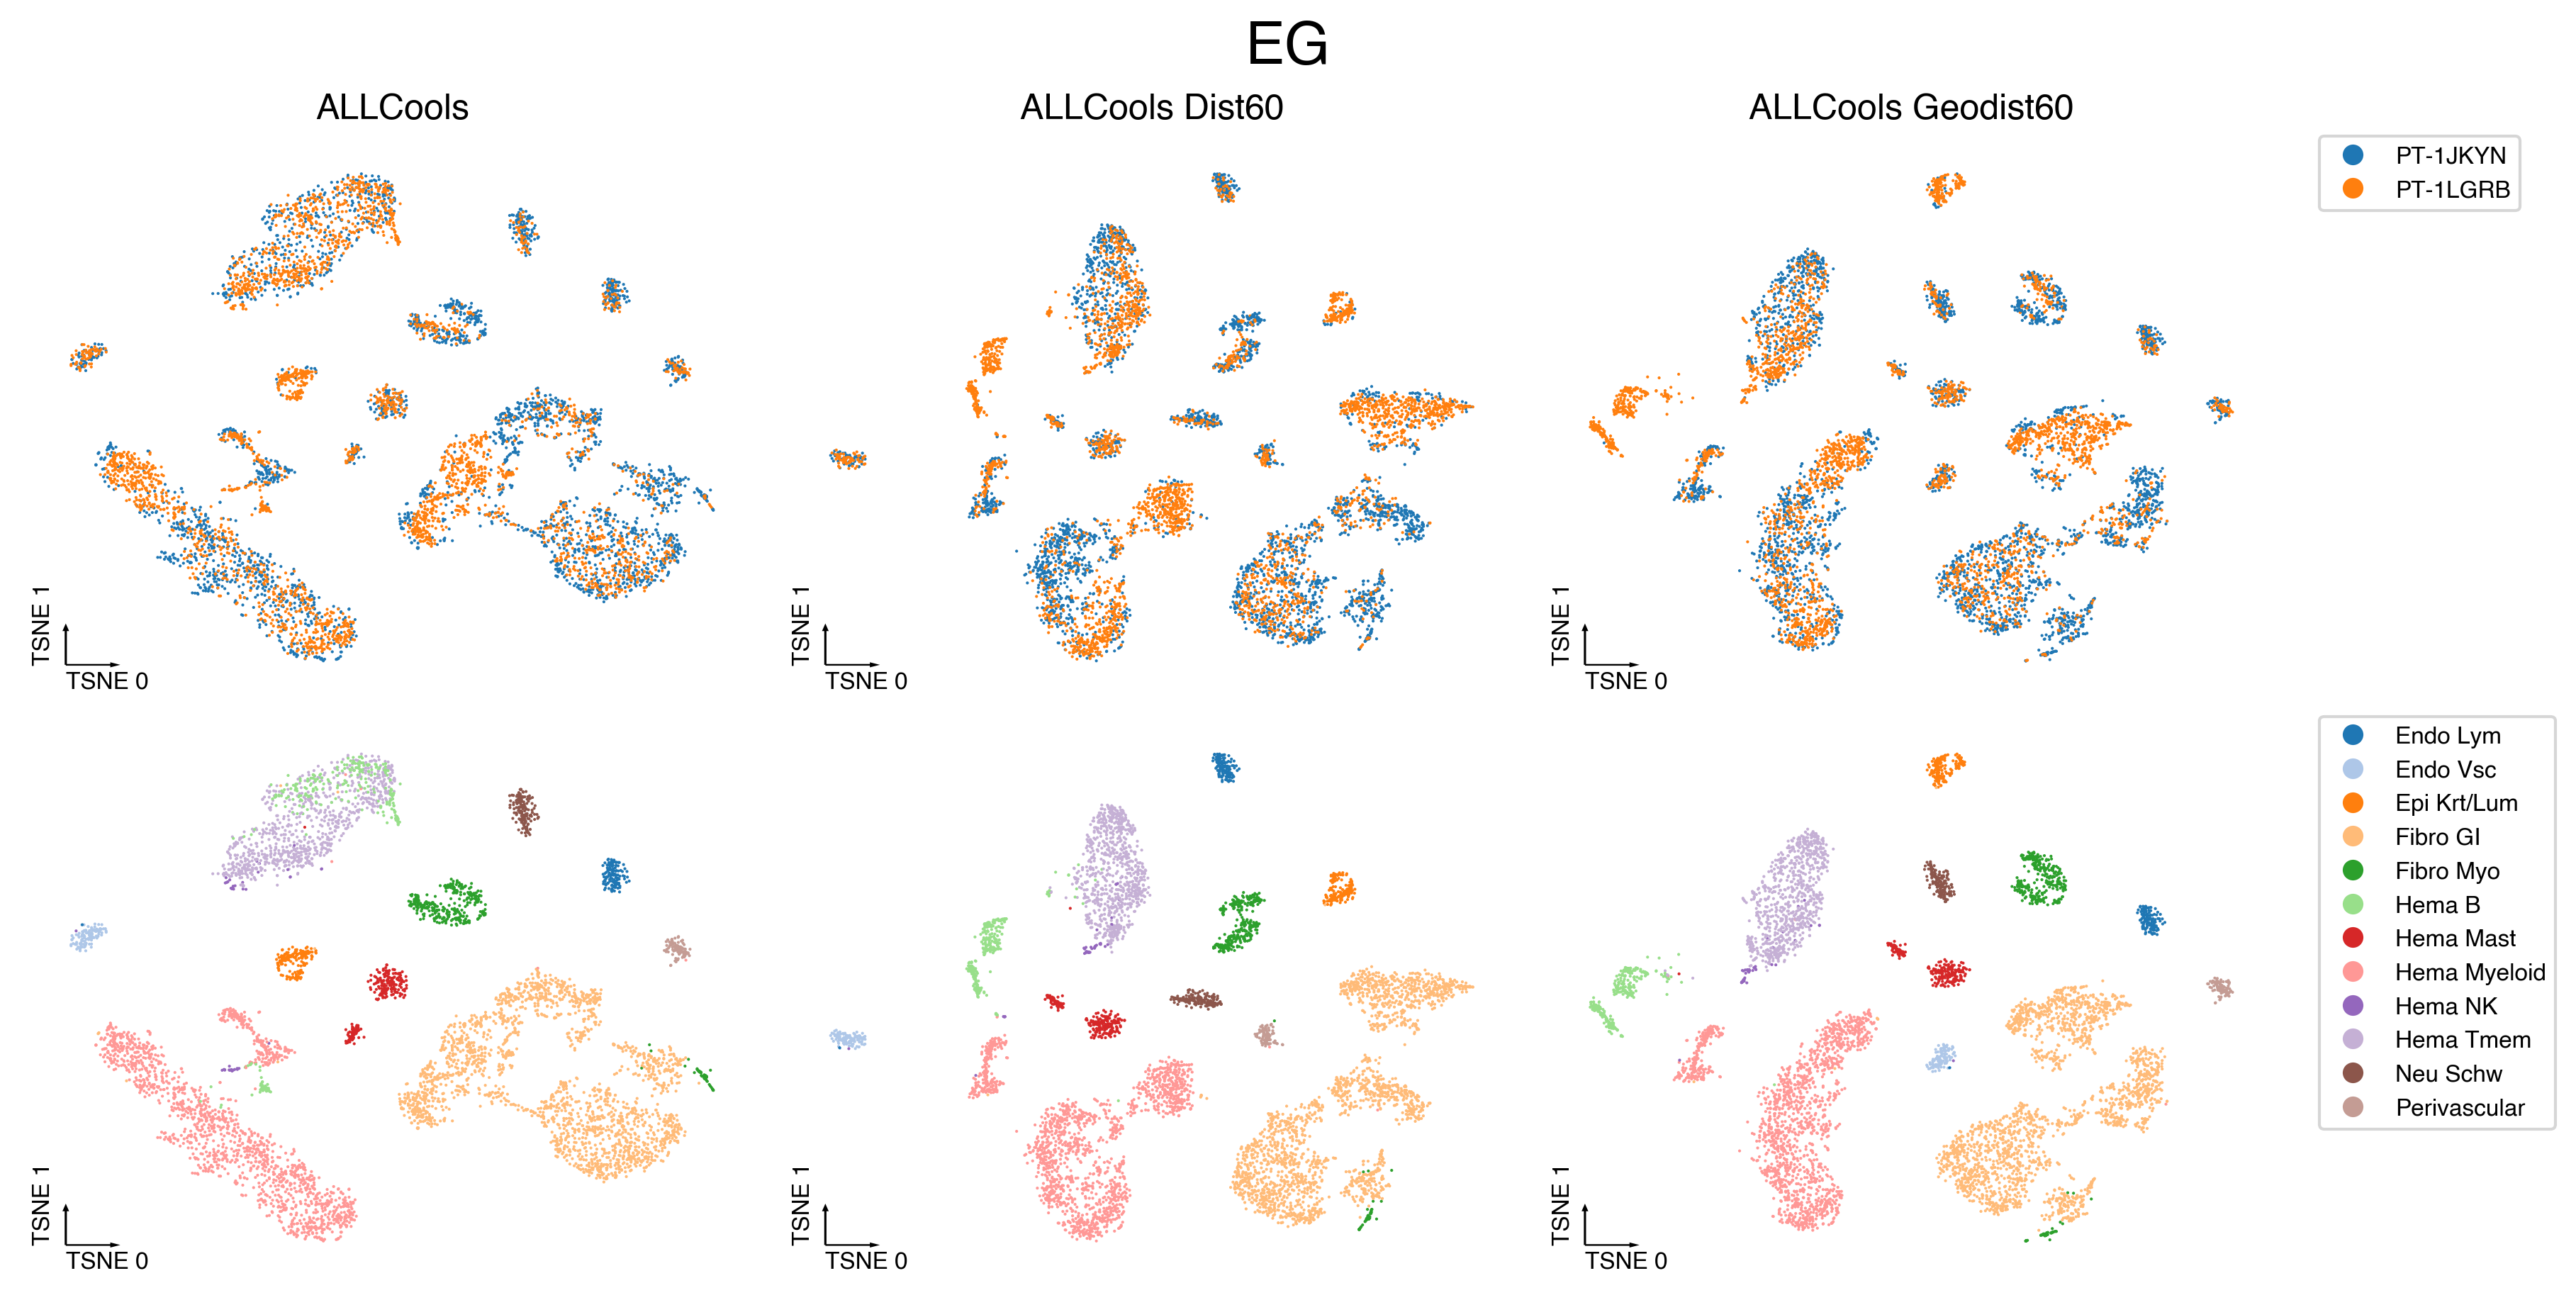

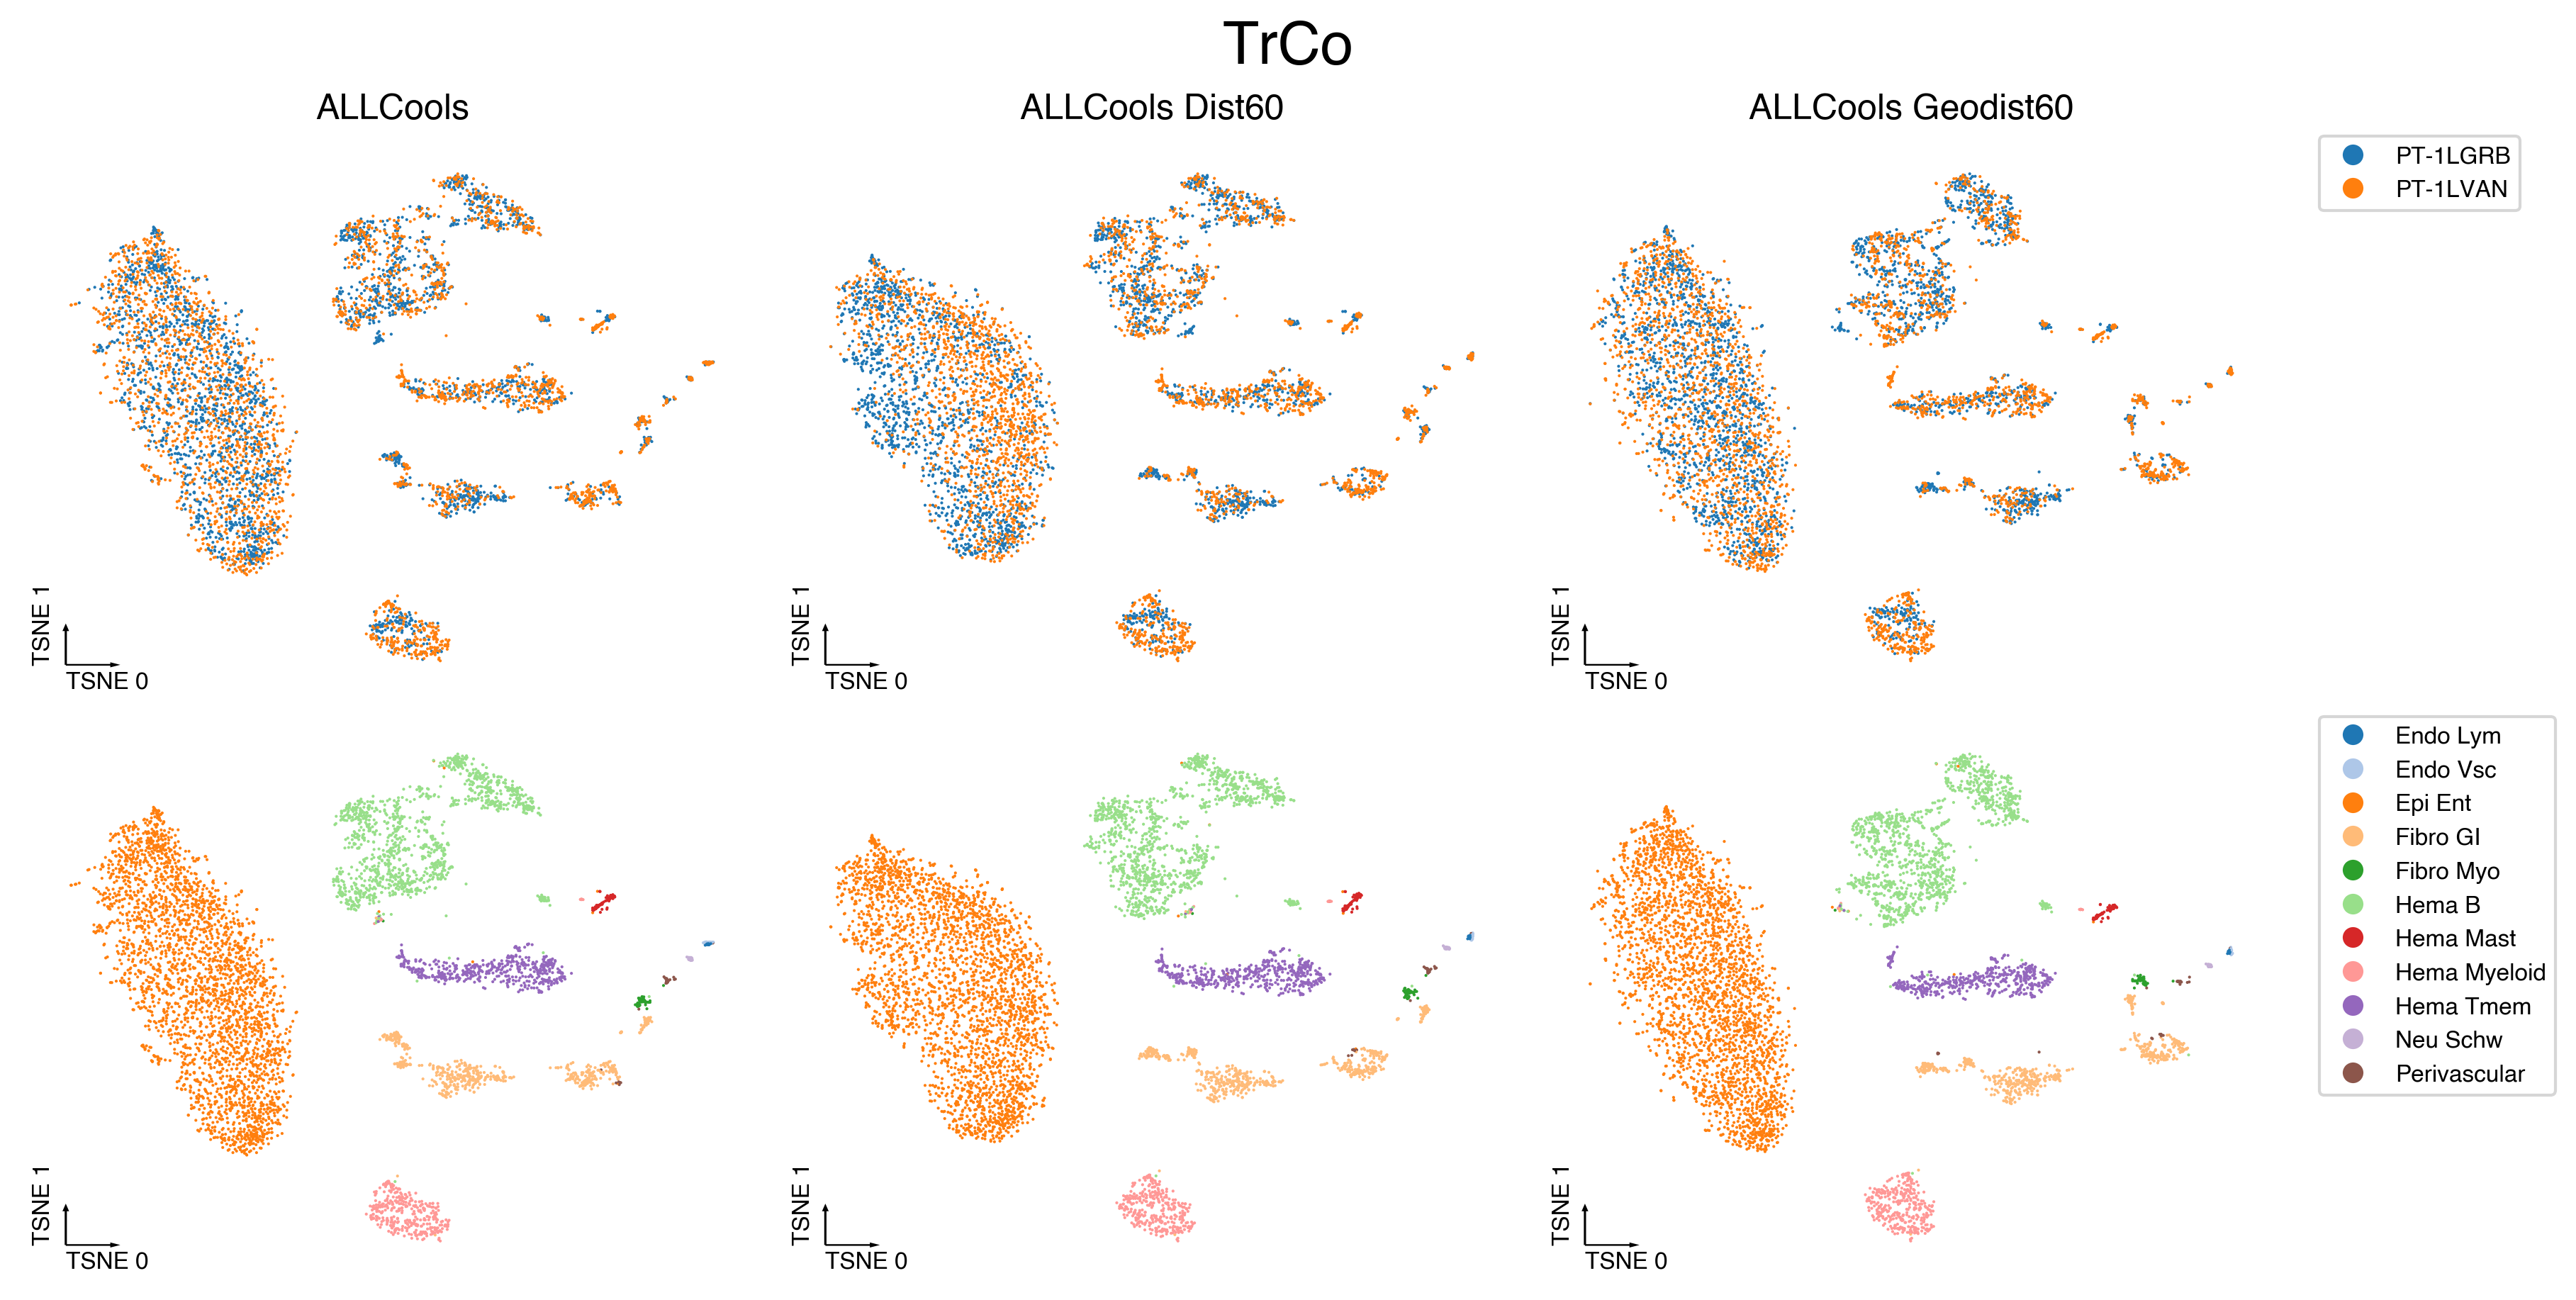

In [14]:
ds = 1
coord_base = 'tsne'
for g in ['EG', 'TrCo']:
    mcad = anndata.read_h5ad(f'{indir}clustering/tissue/L1/{g}/mCG_5kb_lsi.h5ad')
    print(g)
    npc = significant_pc_test(mcad, p_cutoff=0.05, obsm='lsi_all', update=False)
    # if f'5kCG_u{npc}_seuratcc{npc}_tsne' not in mcad.obsm.keys():
    #     mcad.obsm[f'5kCG_u{npc}_seuratcc{npc}_tsne'] = mcad.obsm[f'lsi_u{npc}_seurat_cc{npc}_tsne'].copy()
    #     mcad.obsm[f'5kCG_u{npc}_seuratcc{npc}'] = mcad.obsm[f'lsi_seurat_cc{npc}'].copy()
    #     del mcad.obsm[f'lsi_u{npc}_seurat_cc{npc}_tsne'], mcad.obsm[f'lsi_seurat_cc{npc}']
    #     mcad.write_h5ad(f'{indir}clustering/tissue/{g}/mCG_5kb_lsi.h5ad')

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300, constrained_layout=True)
    fig.suptitle(g, fontsize=20)
    
    for i,method in enumerate([f'_seuratcc{npc}', f'_seuratcc{npc}filter60', f'_seuratcc{npc}geofilter60']):
        
        mcad.obsm[f'X_{coord_base}'] = mcad.obsm[f'5kCG_u{npc}{method}_tsne'].copy()
        dump_embedding(mcad, coord_base)
        mcad.obs['celltype'] = meta.loc[mcad.obs.index, 'majortype'].map(L1_annot)
        count = mcad.obs['celltype'].value_counts()
        selct = count.index[count>=20]
        tmp = mcad.obs.loc[mcad.obs['celltype'].isin(selct)]
        ax = axes[0,i]
        _ = categorical_scatter(data=tmp,
                                ax=ax,
                                coord_base=coord_base,
                                hue='Donor',
                                s=ds,
                                labelsize=8,
                                max_points=None,
                                palette='tab10',
                                scatter_kws={'rasterized':True},
                                show_legend=(i==2))
        ax.set_title(['ALLCools', 'ALLCools Dist60', 'ALLCools Geodist60'][i])

        ax = axes[1,i]
        _ = categorical_scatter(data=tmp,
                                ax=ax,
                                coord_base=coord_base,
                                hue='celltype',
                                # text_anno='celltype', 
                                s=ds,
                                labelsize=8,
                                max_points=None,
                                palette='tab20',
                                scatter_kws={'rasterized':True},
                                legend_kws={'ncol':1}, 
                                show_legend=(i==2))
        
    fig.savefig(f'clustering_summary/mc_lsi_anchormethod_{g}.pdf', transparent=True)
        
        

In [9]:
indir = f'{ENTEX_ROOT}/clustering/tissue/L1/TrCo/'
outdir = f'{ENTEX_ROOT}/analysis/method/'

In [17]:
adata = anndata.read_h5ad(f'{indir}5kCG100k3C_embed.h5ad')
adata

AnnData object with n_obs × n_vars = 5836 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'tsne_0', 'tsne_1', 'L1', 'leiden', 'TissueL1', 'ClusterTissue', 'L1_new', 'leiden_cons', 'leiden_cv'
    obsm: '5kCG100k3C_u21pc14', '5kCG100k3C_u21pc14_tsne', 'X_tsne'

In [27]:
npc = significant_pc_test(adata, p_cutoff=0.05, update=False, obsm='wnn_pc_all')


45 components passed P cutoff of 0.05.


In [ ]:
ds = 4
coord_base = 'tsne'

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, constrained_layout=True)
# `npc` is whatever significant_pc_test picked above (45 in the author's run); use the
# variable so this matches the wnn_pc{npc}_tsne embedding actually written in the tsne cell.
for i,dim_coord in enumerate([f'wnn_pc{npc}', '5kCG100k3C_u21pc14']):
    for j,dim_leiden in enumerate(['leiden_mc', 'leiden_3c']):
        ax = axes[i,j]
        adata.obsm[f'X_{coord_base}'] = adata.obsm[f'{dim_coord}_{coord_base}']
        adata = dump_embedding(adata, coord_base)
        ax.set_title(f'{dim_coord} {dim_leiden}')
        _ = categorical_scatter(data=adata.obs,
                                ax=ax,
                                coord_base=coord_base,
                                hue=dim_leiden,
                                s=ds,
                                labelsize=8,
                                max_points=None,
                                palette='tab20',
                                scatter_kws={'rasterized':True},
                               )

fig.savefig(f'{outdir}TrCo_wnn_concat_leiden.pdf', transparent=True)
